## Example of using functions from package tools

Set up the path for the execution.

In [1]:
import os
from emtk import parsers
from tools import path_similarity, auxiliary, image_generation, setup_paths

paths = setup_paths()
lib_path = paths['lib_path']

Set the experiment_id and trial_id we want to study.

In [2]:
sample_size = 8

Parse the data.

In [3]:
# Parse EMIP data
os.chdir(lib_path)
eye_events, samples = parsers.EMIP(sample_size)

Please cite this paper:  https://dl.acm.org/doi/abs/10.1145/3448018.3457425
parsing file: 100_rawdata.tsv
parsing file: 101_rawdata.tsv
parsing file: 102_rawdata.tsv
parsing file: 103_rawdata.tsv
parsing file: 104_rawdata.tsv
parsing file: 105_rawdata.tsv
parsing file: 106_rawdata.tsv
parsing file: 107_rawdata.tsv


Specify the experiment and trial we want to analyze for the scanpath

In [4]:
# exp = ('experiment_id', 'trial_id')
exp_a = ('103', '2')
exp_b = ('104', '2')

Generate image specified experiment and trial.

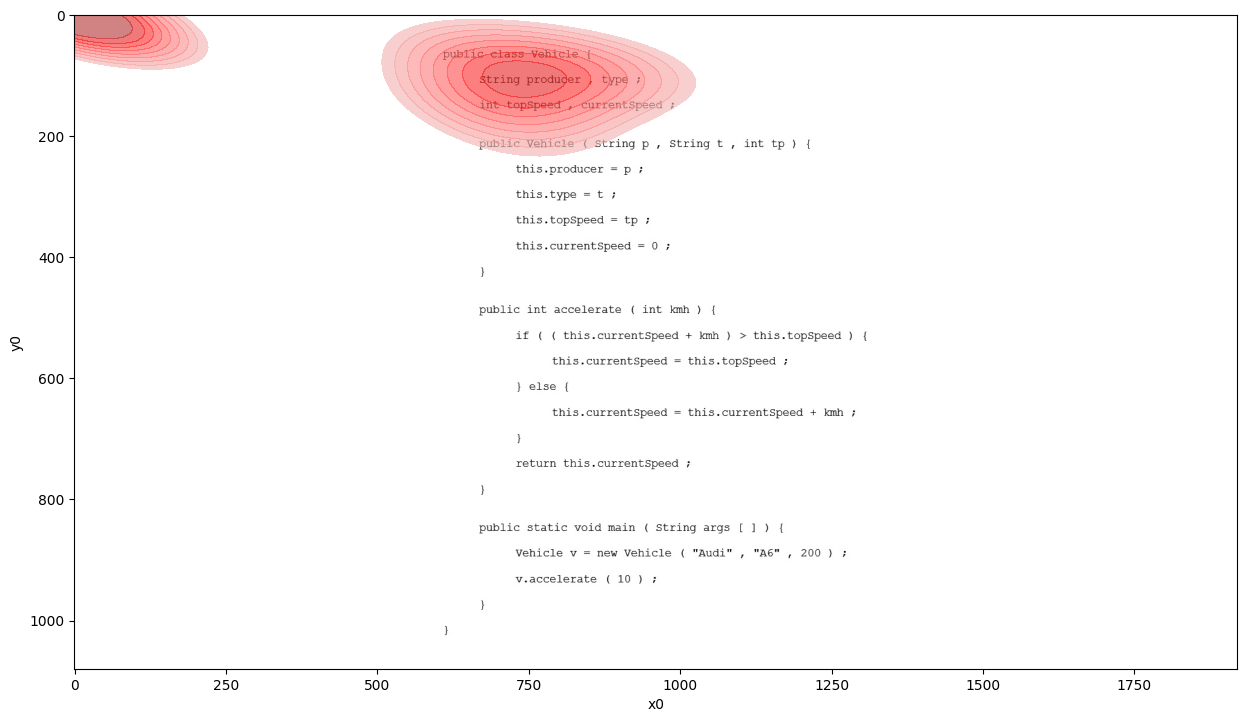

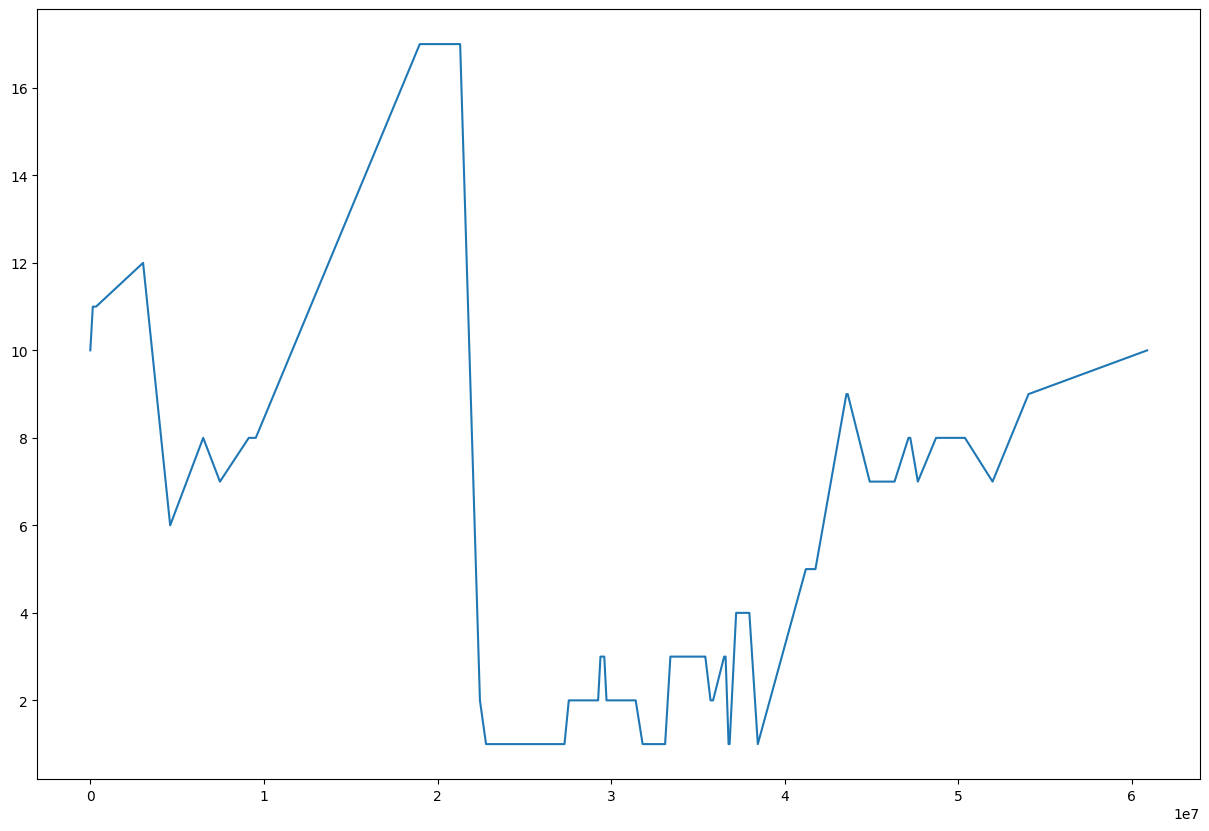

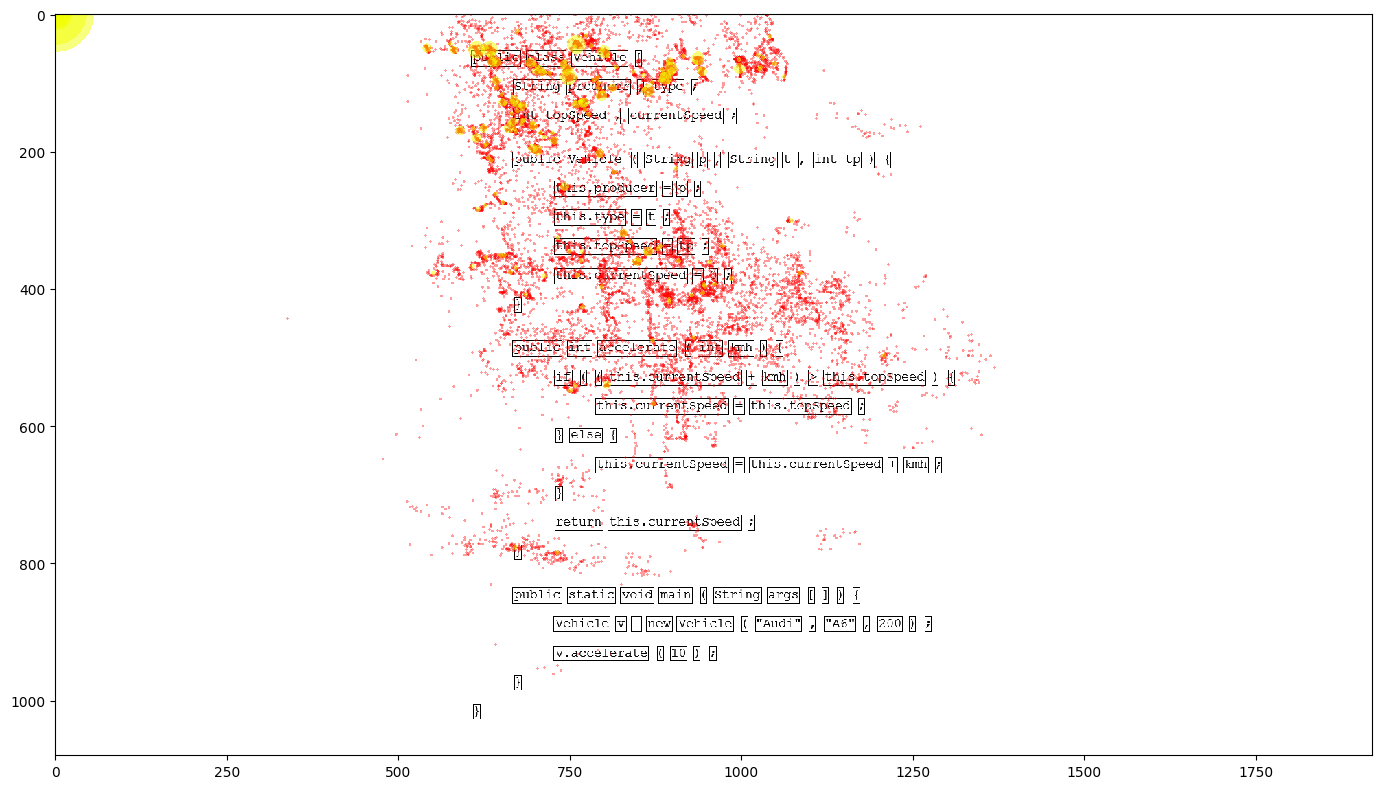

In [5]:
# possible options for image_type are "heatmap", "fixation_duration", "fixation_timeline", "all"
# when query is set to True, the experiment_id will be determined by the query

image_generation.emip_gen(exp = exp_a, eye_events = eye_events, samples = samples, image_type = 'all')

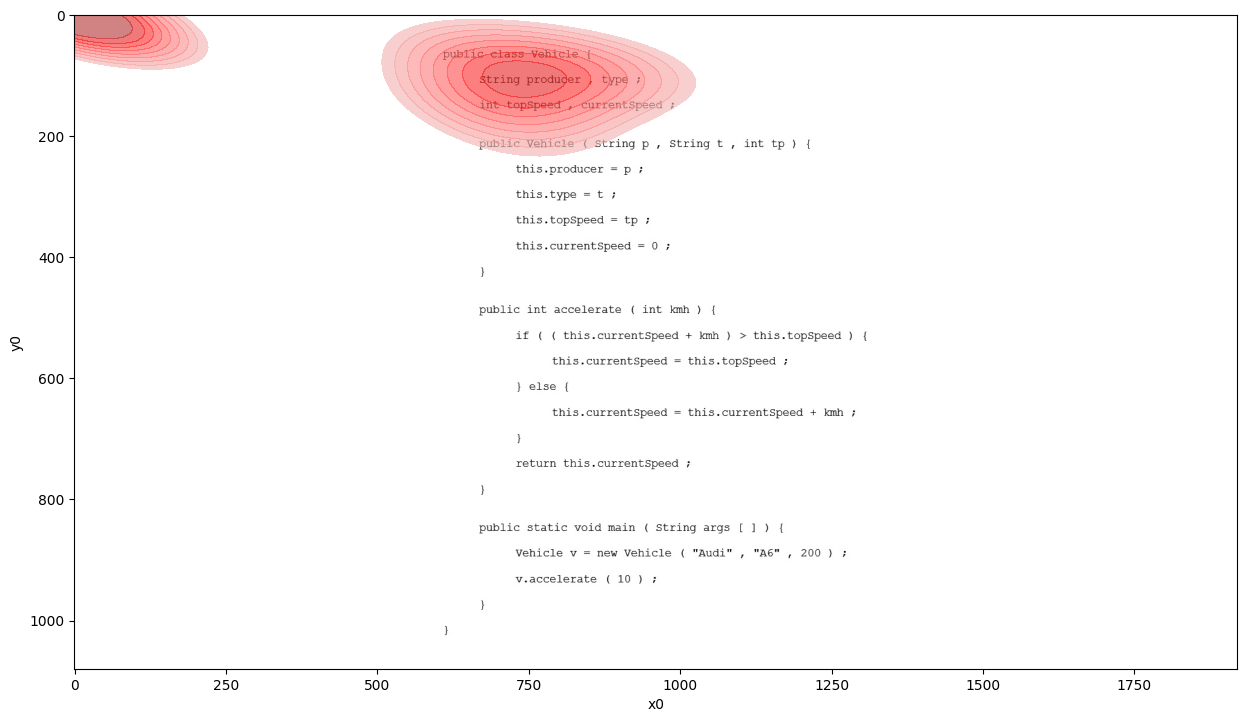

In [6]:
image_generation.emip_gen(exp = exp_a, eye_events = eye_events, samples = samples, image_type = 'heatmap')

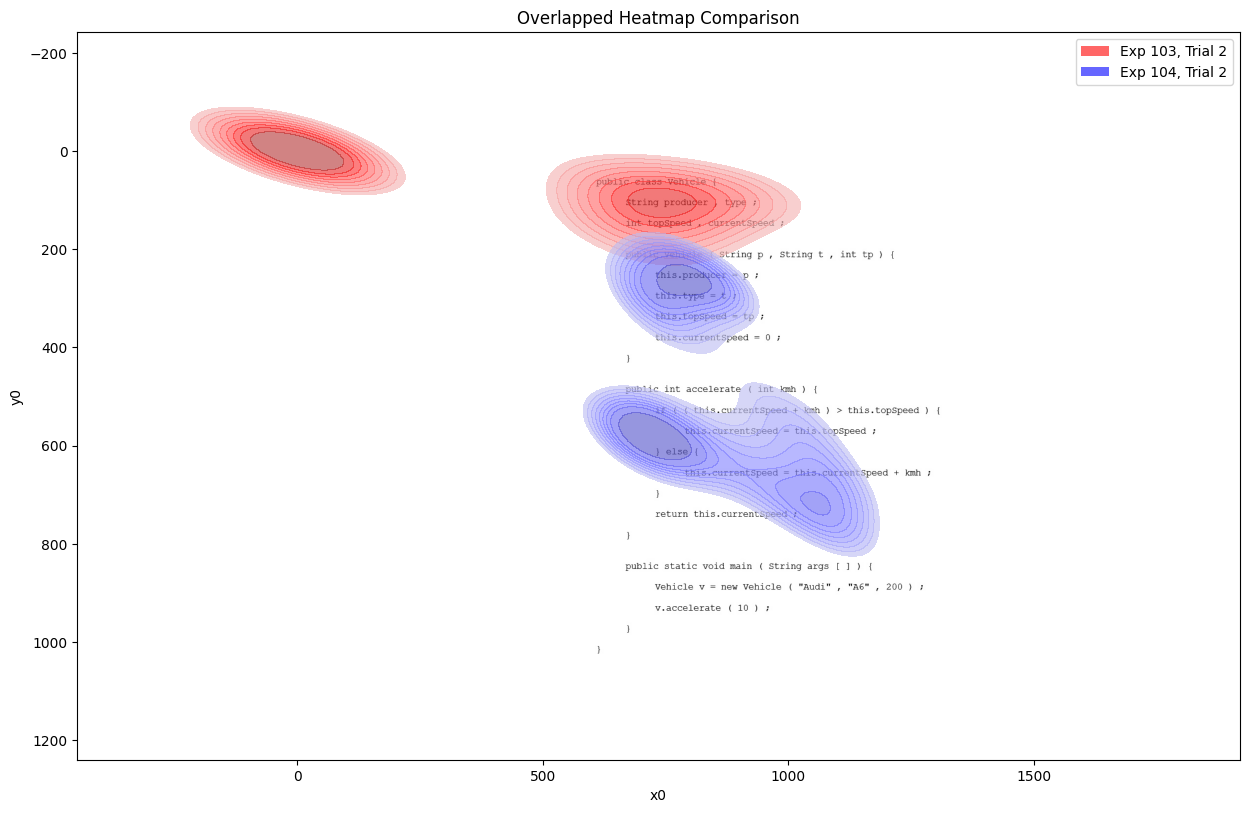

Overlapped heatmap saved to: D:\Storage\ETH\Thesis\Code\output\dataset_images\emip\comparison_exp103_trial2_vs_exp104_trial2_heatmap.png


In [7]:
# Generate overlapped heatmap between two experiments
image_generation.emip_gen(exp = exp_a, eye_events = eye_events, samples = samples, image_type = 'heatmap', compare_exp = exp_b)

Use the python library multimatch_gaze to compute path similarity.\
We use 2 random generated scan-path as baseline to normalize the final value.

final_value = original_value - base_line.

Multimatch Scores:

original_score:
Shape: 0.991165790328598
Direction: 0.5983888666315642
Length: 0.987989502652823
Position: 0.8121709128452096
Duration: 0.7272727272727273

base_line_score:
Shape: 0.8755114105988101
Direction: 0.7329447720097453
Length: 0.8713815665221546
Position: 0.7619355593395074
Duration: 0.8302756113645395

final_score:
Shape: 0.11565437972978787
Direction: -0.13455590537818107
Length: 0.11660793613066844
Position: 0.050235353505702185
Duration: -0.10300288409181224


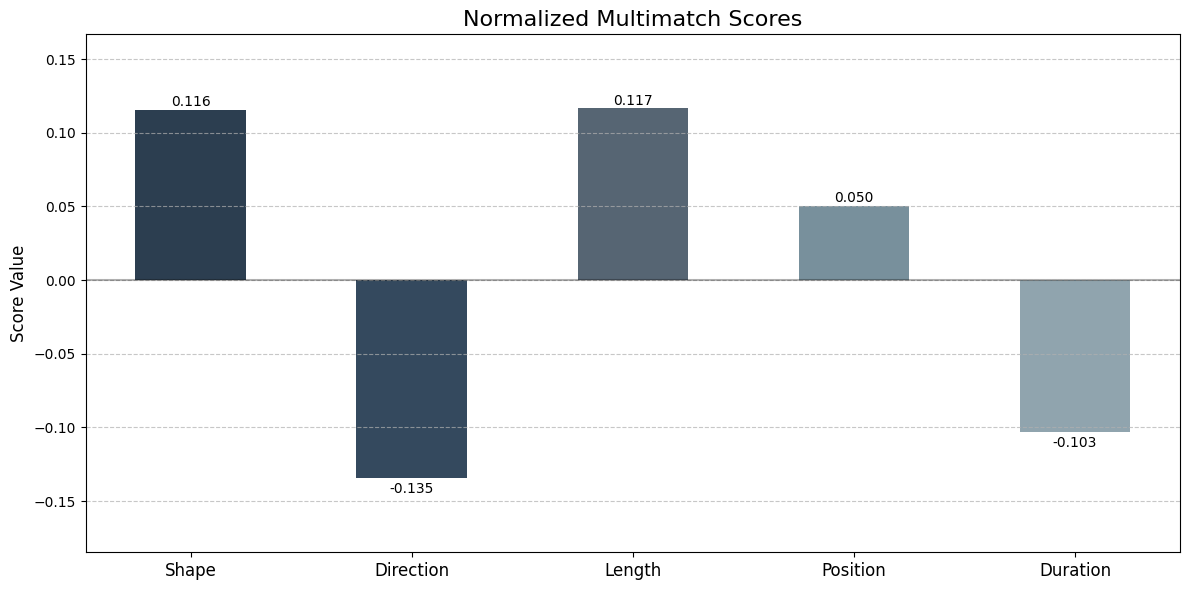

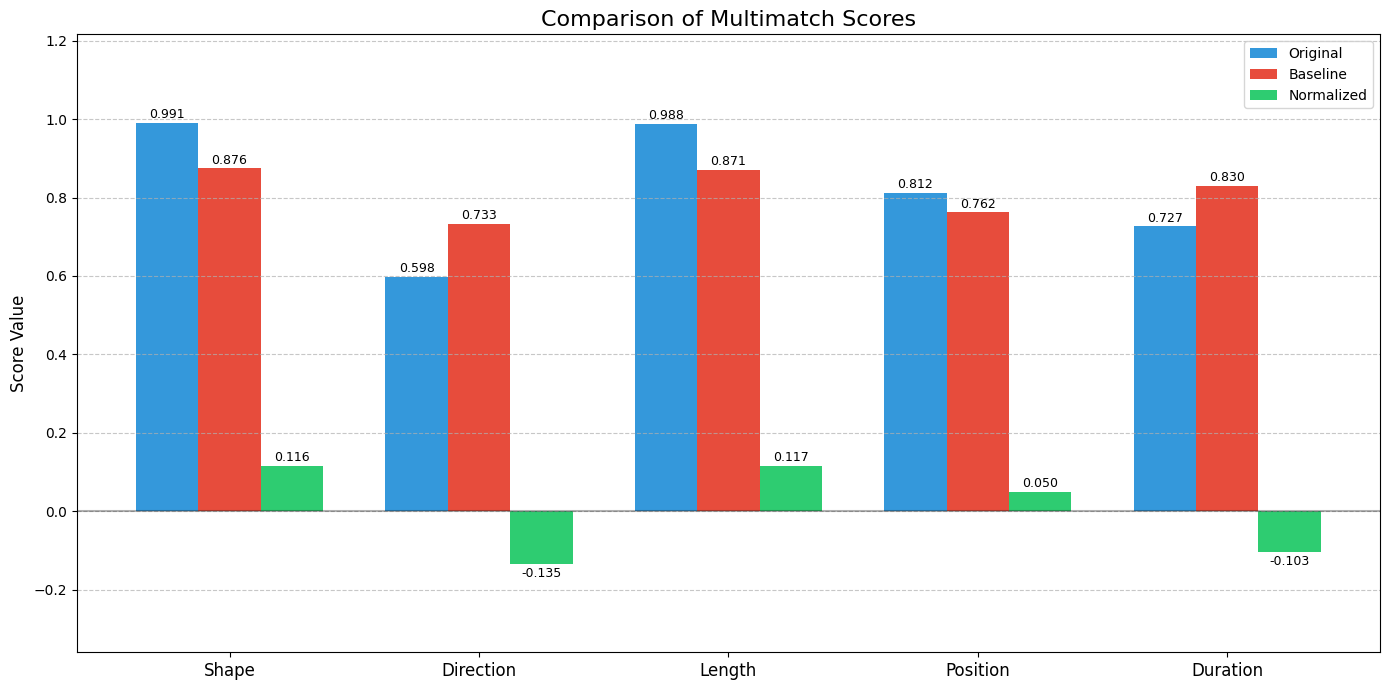

In [8]:
import matplotlib.pyplot as plt
from tools.image_generation import visualize_multimatch_scores, visualize_all_scores

scores = path_similarity.multimatch(
    exp_a=exp_a,
    exp_b=exp_b,
    eye_events=eye_events,
)

print("Multimatch Scores:")
for title, result in scores.items():
    print(f"\n{title}:")
    for key, value in result.items():
        print(f"{key}: {value}")


visualize_multimatch_scores(scores, "EMIP")
plt.show()

visualize_all_scores(scores, "EMIP")
plt.show()

Compute path similarity by using scasim (part of ScanDL)

In [9]:
# parameter normalize can be 'durations', 'fixations' or 'None'
# It actually compute Scan path difference
scores = path_similarity.scasim(
    exp_a=exp_a,
    exp_b=exp_b,
    eye_events=eye_events,
    normalize = 'duration',
    data_set = 'original',
)

print("Scasim score:", scores["original_score"])
# print("Normalized Scasim score:", scores["final_score"])

Scasim score: 0.8506936803968832


Compute NLD for both scanpath

In [10]:
scores = path_similarity.nld(exp_a, exp_b, eye_events, data_set="original")

print(f"Distance: {scores['original_distance']}, NLD: {scores['original_nld']}")
# print(f"Normalized: Distance: {scores['final_distance']}, NLD: {scores['final_nld']}")

Distance: 337.0, NLD: 0.9711815561959655


# Use corrected EMIP dataset

In [11]:
from tools import auxiliary, path_similarity

eye_events_corrected = auxiliary.parse_corrected_emip_data()
allowed_experiments = eye_events_corrected['experiment_id'].dropna().unique()

# exp = ('experiment_id', 'trial_id')
exp_a = ('135', '2')
exp_b = ('145', '2')

if exp_a[0] not in allowed_experiments:
    print(f"Experiment {exp_a[0]} is not allowed.")
    raise SystemExit("Not allowed experiment id")

if exp_b[0] not in allowed_experiments:
    print(f"Experiment {exp_b[0]} is not allowed.")
    raise SystemExit("Not allowed experiment id")

Multimatch Scores (Corrected Data):

original_score:
Shape: 0.9898216570194479
Direction: 0.6849207781193991
Length: 0.9867133353213695
Position: 0.864653626104004
Duration: 0.7655677655677655

base_line_score:
Shape: 0.8693333731082286
Direction: 0.7205478343571226
Length: 0.8705667852933068
Position: 0.7674162062695261
Duration: 0.8342291209283398

final_score:
Shape: 0.12048828391121935
Direction: -0.03562705623772344
Length: 0.11614655002806273
Position: 0.09723741983447787
Duration: -0.06866135536057427


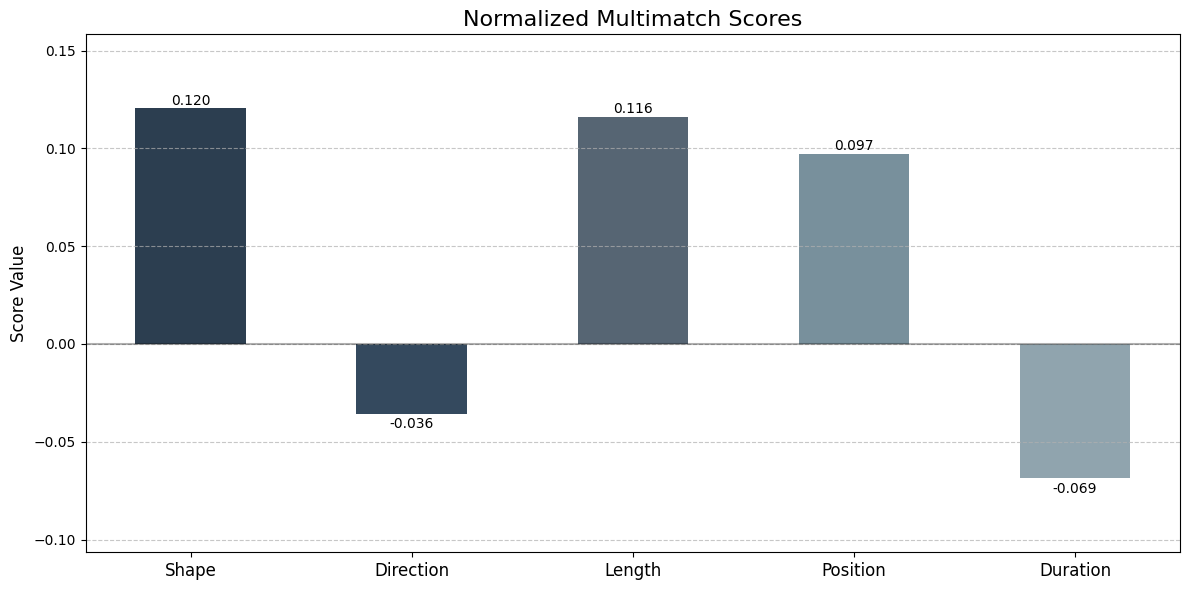

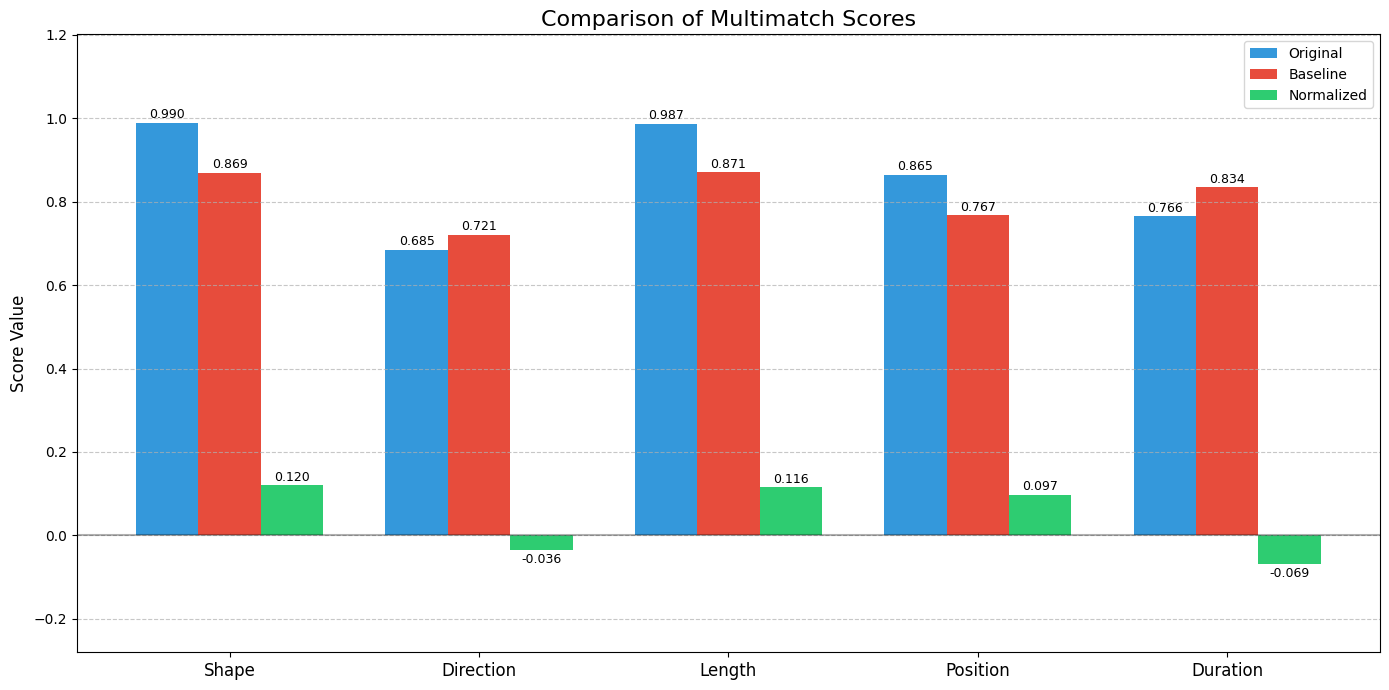

In [12]:
import matplotlib.pyplot as plt
from tools.image_generation import visualize_multimatch_scores, visualize_all_scores

scores = path_similarity.multimatch(
    exp_a=exp_a,
    exp_b=exp_b,
    eye_events=eye_events_corrected,
)

print("Multimatch Scores (Corrected Data):")
for title, result in scores.items():
    print(f"\n{title}:")
    for key, value in result.items():
        print(f"{key}: {value}")


visualize_multimatch_scores(scores, "Corrected EMIP")
plt.show()

visualize_all_scores(scores, "Corrected EMIP")
plt.show()

In [13]:
scores = path_similarity.scasim(
    exp_a=exp_a,
    exp_b=exp_b,
    eye_events=eye_events_corrected,
    normalize = 'duration',
    data_set = 'corrected',
)

print("Scasim score:", scores["original_score"])
# print("Normalized Scasim score:", scores["final_score"])

Scasim score: 0.8295406462753452


In [14]:
scores = path_similarity.nld(exp_a, exp_b, eye_events_corrected, data_set="corrected")

print(f"Distance: {scores['original_distance']}, NLD: {scores['original_nld']}")
# print(f"Normalized: Distance: {scores['final_distance']}, NLD: {scores['final_nld']}")

Distance: 354.0, NLD: 0.9123711340206185
